# CLIP + SAM

In [1]:
# install necessary modules
import sys

!{sys.executable} -m pip install dlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 16.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dlib: filename=dlib-19.24.5-cp310-cp310-macosx_13_0_arm64.whl size=3138429 sha256=ef28e4ca9c2feb7526a2b6807b4592d8e3caa2aec120072d4d89f6ba84925d60
  Stored in directory: /Users/andriimatsevytyi/Library/Caches/pip/wheels/96/c0/80/7cda8c6ba7dc0668f4de743aaff351300f43771cb71b54b847
Successfully built dlib

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [43]:
# necesary imports

import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt

In [89]:
def highlight_landmarks(image_path):

    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor('../checkpoints/shape_predictor_68_face_landmarks.dat')

    # Load the face image
    face_img = cv2.imread(image_path)

    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    faces = detector(gray)
    if len(faces) == 0:
        raise ValueError("No faces detected")

    # Detect facial landmarks for the first face
    face = faces[0]
    landmarks = predictor(gray, face)
    
    angle = get_face_angle(face_img, landmarks)[1]
    
    if angle > 0:
        print(f'{abs(angle):.2f} degrees left')
    elif angle < 0:
        print(f'{abs(angle):.2f}  degrees right')
    
    point_size = int(face_img.shape[0] / 800) ** 2
    
    print(point_size)

    for i in range(68):  # 68 landmarks in total
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        cv2.circle(face_img, (x, y), point_size, (240, 0, 0), -1)  # highlight with red circles
    
    return face_img


# this function will be useful now 
# (when we do just front photo of eyeglasses excluding temples) 
# and later if we would want to apply 3D changes
# it prints angle of the face (yaw, should be near 0)
 
def get_face_angle(face_img, landmarks):
    
    image_points = np.array([
        (landmarks.part(30).x, landmarks.part(30).y),  # Nose tip
        (landmarks.part(8).x, landmarks.part(8).y),    # Chin
        (landmarks.part(36).x, landmarks.part(36).y),  # Left eye left corner
        (landmarks.part(45).x, landmarks.part(45).y),  # Right eye right corner
        (landmarks.part(48).x, landmarks.part(48).y),  # Left Mouth corner
        (landmarks.part(54).x, landmarks.part(54).y)   # Right Mouth corner
    ], dtype="double")
    
    # approximate positions of key facial landmarks in a generic 3D space (in mm)
    model_points = np.array([
        (0.0, 0.0, 0.0),          # Nose tip
        (0.0, -330.0, -65.0),     # Chin
        (-225.0, 170.0, -135.0),  # Left eye left corner
        (225.0, 170.0, -135.0),   # Right eye right corner
        (-150.0, -150.0, -125.0), # Left Mouth corner
        (150.0, -150.0, -125.0)   # Right Mouth corner
    ])
    
    # Camera matrix
    focal_length = face_img.shape[1]
    center = (face_img.shape[1] // 2, face_img.shape[0] // 2)
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype="double")

    # Assuming no lens distortion
    dist_coeffs = np.zeros((4,1))

    # Solve PnP
    (success, rotation_vector, translation_vector) = cv2.solvePnP(
        model_points, image_points, camera_matrix, dist_coeffs, flags=cv2.SOLVEPNP_ITERATIVE
    )

    # Convert rotation vector to rotation matrix
    rotation_matrix, _ = cv2.Rodrigues(rotation_vector)

    # Compute yaw, pitch, and roll
    def rotation_matrix_to_euler_angles(R):
        sy = np.sqrt(R[0, 0] ** 2 + R[1, 0] ** 2)
        singular = sy < 1e-6

        if not singular:
            x = np.arctan2(R[2, 1], R[2, 2])
            y = np.arctan2(-R[2, 0], sy)
            z = np.arctan2(R[1, 0], R[0, 0])
        else:
            x = np.arctan2(-R[1, 2], R[1, 1])
            y = np.arctan2(-R[2, 0], sy)
            z = 0

        return np.degrees(x), np.degrees(y), np.degrees(z)

    pitch, yaw, roll = rotation_matrix_to_euler_angles(rotation_matrix)
    
    return pitch, yaw, roll


6.44  degrees right
9


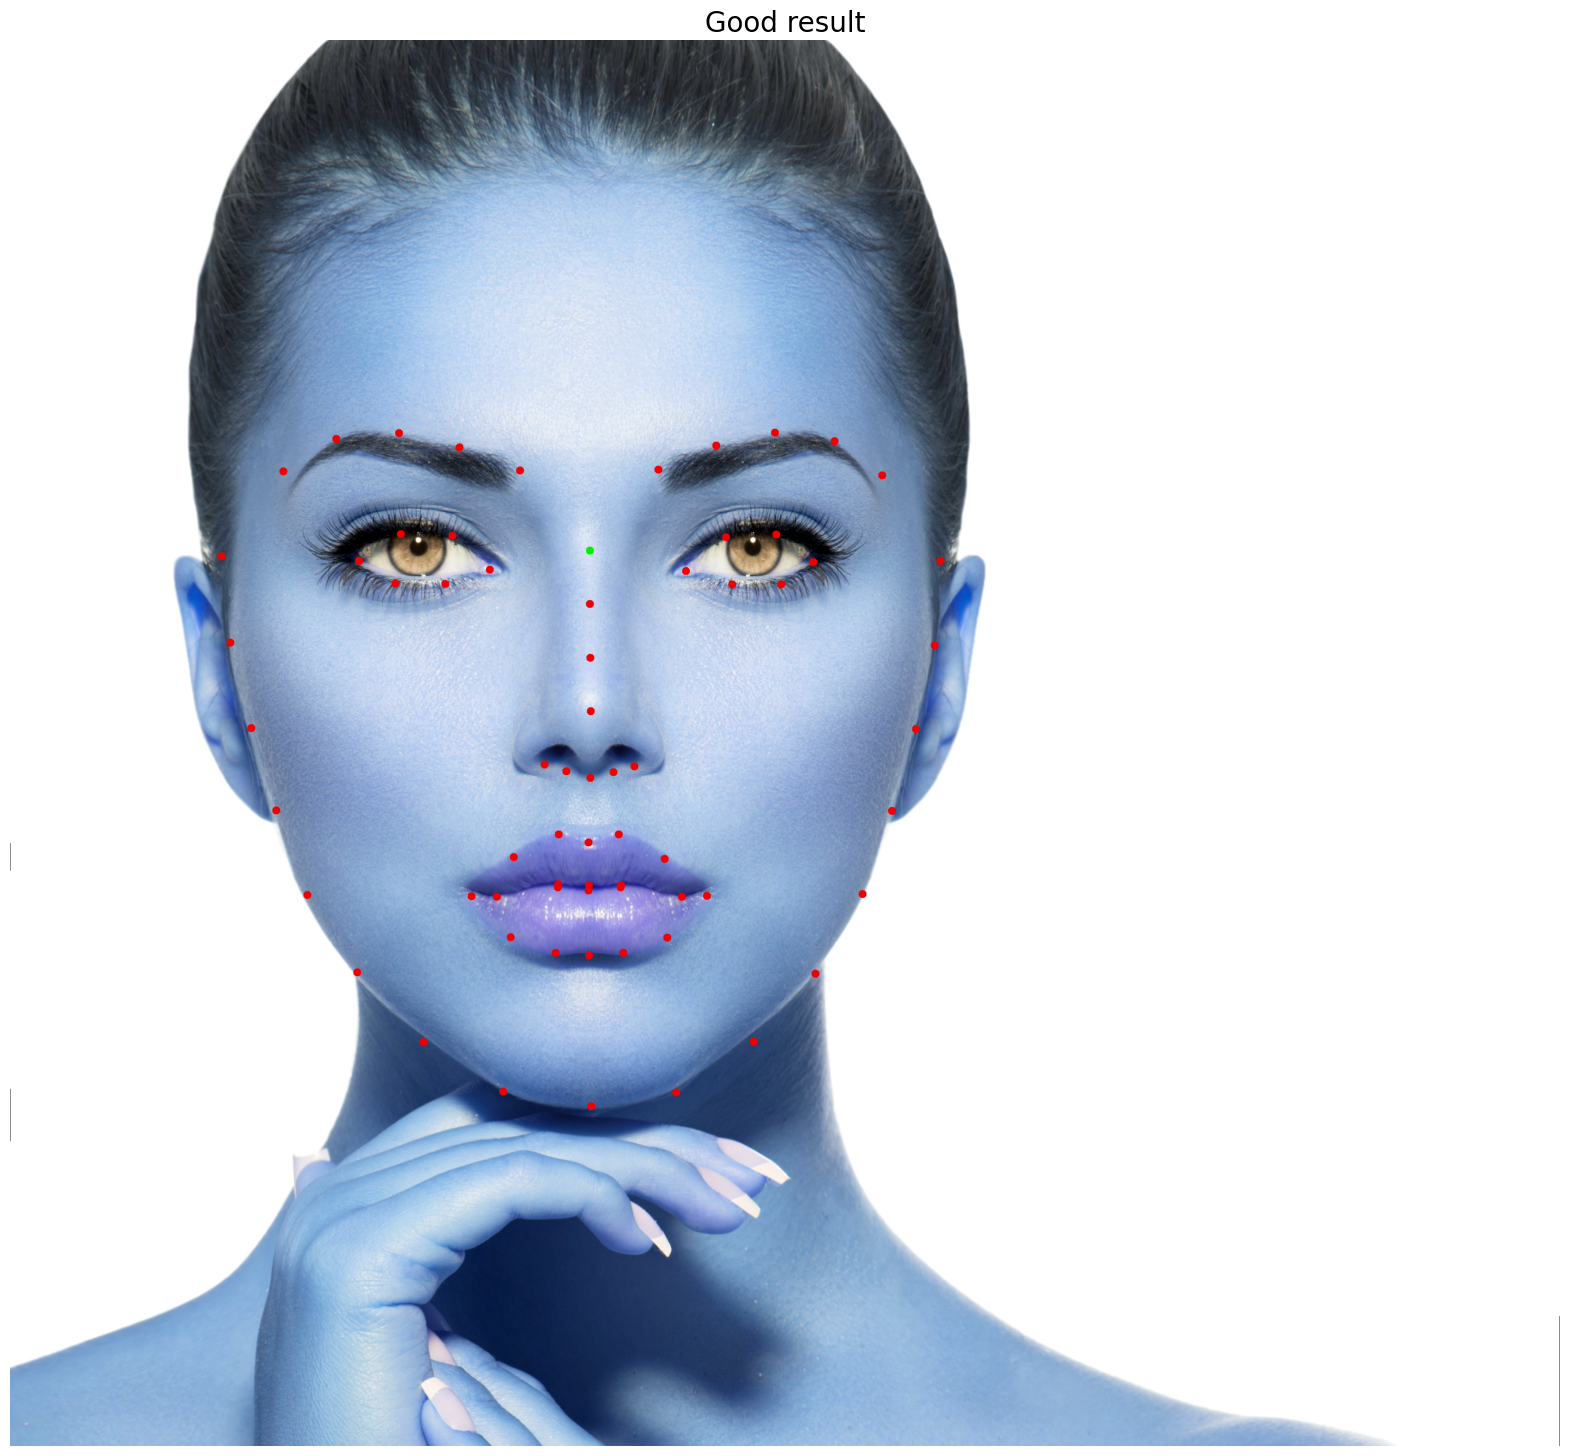

In [90]:
# Example usage
result = highlight_landmarks('../images/0.jpg')